# Hooplytics Powered by Python

**Author:** Chris Campbell  
**Stack:** `nba_api` · `pandas` · `scikit-learn` · `seaborn` · `plotly`  
**Python:** 3.11+

`hooplytics` is the Python port of [hooplyticsR](https://github.com/texasbe2trill/hooplyticsR). It analyzes NBA player performance using descriptive statistics, distributional visualizations, and supervised machine-learning models trained on historical box scores.

This notebook is organized as a narrative report:

1. **Setup & data ingestion** — pull per-game logs from the official NBA Stats API.
2. **Player statistics** — averages, standard deviations, and a fantasy score.
3. **Performance visualizations** — faceted histograms, KDEs, and an interactive radar.
4. **Predictive modeling** — kNN and Random Forest regressors with cross-validated tuning.
5. **Fantasy decisions** — combine projections with model predictions to produce More/Less calls.


## 1. Setup

We'll fetch each player's regular-season game logs season-by-season via [`nba_api`](https://github.com/swar/nba_api) and cache results to disk so re-runs don't hit the network.

In [1]:
# ── Package bootstrap ─────────────────────────────────────────────────────────
# Checks whether each required package is importable and installs any that are
# missing. Uses %pip (via IPython) rather than subprocess so that newly installed
# packages are immediately visible to the running kernel — no restart required.
# No-op in a local venv where everything is already installed.
import importlib.util
import sys

_REQUIRED = [
    ("nba_api",     "nba_api>=1.4.1"),
    ("pandas",      "pandas>=2.2"),
    ("numpy",       "numpy>=2.1"),
    ("sklearn",     "scikit-learn>=1.5"),
    ("matplotlib",  "matplotlib>=3.9"),
    ("seaborn",     "seaborn>=0.13"),
    ("plotly",      "plotly>=5.24"),
    ("pyarrow",     "pyarrow>=17.0"),
    ("tqdm",        "tqdm>=4.66"),
    ("ipywidgets",  "ipywidgets>=8.1"),
]

_missing = [pkg for mod, pkg in _REQUIRED if importlib.util.find_spec(mod) is None]

if _missing:
    print(f"Installing: {', '.join(_missing)}")
    # get_ipython().run_line_magic("pip", ...) is equivalent to %pip install.
    # Unlike subprocess, it updates sys.path in the current process so imports
    # work in the very next cell without a kernel restart.
    get_ipython().run_line_magic("pip", f"install -q {' '.join(_missing)}")  # noqa: F821
    print("✅ Done — packages installed.")
else:
    print("✅ All packages present.")


✅ All packages present.


In [2]:
from __future__ import annotations

import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, RepeatedKFold, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from nba_api.stats.endpoints import playergamelog
from nba_api.stats.static import players as nba_players

# typing.NotRequired requires 3.11+; 3.14 was used during development.
if sys.version_info < (3, 11):
    raise RuntimeError(f"Python 3.11+ required, got {sys.version}")

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="talk")
RNG = np.random.default_rng(123)

CACHE_DIR = Path("data/cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Python {sys.version.split()[0]}  |  pandas {pd.__version__}  |  numpy {np.__version__}")


Python 3.14.3  |  pandas 3.0.2  |  numpy 2.4.4


### 1.1 Configure your roster

Run the cell below to launch an interactive **roster builder** powered by `ipywidgets` — works in VS Code, JupyterLab, and Google Colab.

**How to use it:**

1. **Pick a season range.** Adjust the *Start year* and *End year* boxes (NBA seasons are labeled by their start year, so `2023 → 2025` means the `2023-24`, `2024-25`, and `2025-26` regular seasons).
2. **Add players.** Click in the **Add player** box and start typing — the dropdown filters live against every active NBA player. Pick from the menu (or type a full name) and click **Add**. Repeat for every player you want to analyze. The default roster (LeBron, KD, Wemby) is pre-loaded — click **Remove** on any row to drop it.
3. **Tweak projections inline.** Each player's row has a number box per stat (`points`, `fantasy_score`, `pra`, `threepm`, `assists`). These feed §5's More/Less engine. Leave them at the defaults if you don't have specific lines.
4. **Click ✅ Done — Build roster.** This locks in `ROSTER`, `SEASONS`, `CURRENT`, and `PLAYERS` for the rest of the notebook. Then run §1.2 onward.

> 💡 5-game averages are still **auto-derived** from the most recent games — no manual updates needed week to week.


In [ ]:
from typing import NotRequired, TypedDict

import ipywidgets as widgets
from IPython.display import display

from nba_api.stats.static import players as nba_players

# Google Colab needs an explicit opt-in to render ipywidgets >=8 via the
# custom widget manager — without this the cell output is blank.
# No-op (and safely ignored) outside Colab.
try:
    from google.colab import output as _colab_output  # type: ignore
    _colab_output.enable_custom_widget_manager()
except Exception:
    pass


class RosterEntry(TypedDict):
    seasons: list[str]
    proj: NotRequired[dict[str, float]]  # sportsbook-style baselines per model name


def nba_seasons(start: int, end: int) -> list[str]:
    """Inclusive range of NBA-style season strings, e.g. nba_seasons(2023, 2025) -> ['2023-24','2024-25','2025-26']."""
    return [f"{y}-{str(y + 1)[-2:]}" for y in range(start, end + 1)]


# Stats that the More/Less engine knows how to project.
PROJ_STATS = ["points", "fantasy_score", "pra", "threepm", "assists"]

# Sensible defaults so users can just hit "Done" without editing anything.
DEFAULT_ROSTER: dict[str, dict[str, float]] = {
    "LeBron James":      {"points": 21.5, "fantasy_score": 41.5, "pra": 34.0, "threepm": 1.5, "assists": 7.0},
    "Kevin Durant":      {"points": 26.0, "fantasy_score": 42.0, "pra": 36.0, "threepm": 2.5, "assists": 4.5},
    "Victor Wembanyama": {"points": 25.0, "fantasy_score": 53.0, "pra": 39.5, "threepm": 1.5, "assists": 3.0},
}

FANTASY_WEIGHTS = dict(pts=1.0, reb=1.2, ast=1.5, stl=3.0, blk=3.0, tov=-1.0)


def fantasy(df: pd.DataFrame) -> pd.Series:
    return sum(df[c] * w for c, w in FANTASY_WEIGHTS.items())  # type: ignore[return-value]


# ── Pre-seed globals so re-running downstream cells without clicking "Done" still works. ──
SEASONS_INPUT: list[str] = nba_seasons(2023, 2025)
CURRENT: list[str] = SEASONS_INPUT
ROSTER: dict[str, RosterEntry] = {
    name: {"seasons": SEASONS_INPUT, "proj": dict(proj)} for name, proj in DEFAULT_ROSTER.items()
}
PLAYERS: list[str] = list(ROSTER)
SEASONS: list[str] = sorted({s for entry in ROSTER.values() for s in entry["seasons"]})

# ── Roster-builder UI (ipywidgets) ────────────────────────────────────────────
# Combobox.options must be plain strings; we feed it every active NBA player so
# the dropdown filters live as the user types.
_ALL_NBA_PLAYERS: list[dict] = nba_players.get_players()
_ACTIVE_PLAYER_NAMES: list[str] = sorted(
    p["full_name"] for p in _ALL_NBA_PLAYERS if p.get("is_active")
)
_ALL_PLAYER_NAMES: list[str] = sorted(p["full_name"] for p in _ALL_NBA_PLAYERS)

# Working copy that the UI mutates; copied into ROSTER on "Done".
_pending_roster: dict[str, dict[str, float]] = {
    name: dict(proj) for name, proj in DEFAULT_ROSTER.items()
}

# ---- widgets ----
_start_year = widgets.BoundedIntText(
    value=2023, min=1946, max=2030, step=1,
    description="Start year:", style={"description_width": "100px"},
    layout=widgets.Layout(width="220px"),
)
_end_year = widgets.BoundedIntText(
    value=2025, min=1946, max=2030, step=1,
    description="End year:", style={"description_width": "100px"},
    layout=widgets.Layout(width="220px"),
)
_player_search = widgets.Combobox(
    placeholder="Type a name (e.g. 'leb' → LeBron James)…",
    options=_ACTIVE_PLAYER_NAMES,
    ensure_option=False,  # allow free-form entry as a fallback
    description="Add player:", style={"description_width": "100px"},
    layout=widgets.Layout(width="540px"),
)
_include_retired = widgets.Checkbox(
    value=False, description="Include retired players in suggestions",
    indent=False, layout=widgets.Layout(width="320px"),
)
_add_btn = widgets.Button(
    description="Add", button_style="primary", icon="plus",
    layout=widgets.Layout(width="100px"),
)
_done_btn = widgets.Button(
    description="✅ Done — Build roster", button_style="success",
    layout=widgets.Layout(width="240px"),
)
_status = widgets.HTML()
_players_box = widgets.VBox()


def _on_include_retired(change):
    _player_search.options = _ALL_PLAYER_NAMES if change["new"] else _ACTIVE_PLAYER_NAMES


_include_retired.observe(_on_include_retired, names="value")


def _render_players() -> None:
    """Re-draw the per-player projection rows from `_pending_roster`."""
    rows: list[widgets.Widget] = []
    for name, proj in _pending_roster.items():
        header = widgets.HTML(f"<b style='font-size:14px'>{name}</b>")
        proj_inputs: list[widgets.Widget] = []
        for stat in PROJ_STATS:
            w = widgets.FloatText(
                value=float(proj.get(stat, 0.0)),
                description=stat, step=0.5,
                style={"description_width": "100px"},
                layout=widgets.Layout(width="190px"),
            )

            def _on_change(change, n=name, s=stat):
                _pending_roster[n][s] = float(change["new"])

            w.observe(_on_change, names="value")
            proj_inputs.append(w)

        remove = widgets.Button(
            description="Remove", button_style="warning", icon="trash",
            layout=widgets.Layout(width="110px"),
        )

        def _on_remove(_btn, n=name):
            _pending_roster.pop(n, None)
            _render_players()

        remove.on_click(_on_remove)

        rows.append(widgets.VBox(
            [widgets.HBox([header, remove]), widgets.HBox(proj_inputs)],
            layout=widgets.Layout(border="1px solid #ddd", padding="8px",
                                  margin="4px 0", border_radius="6px"),
        ))
    _players_box.children = tuple(rows)
    _status.value = (
        f"<i>Pending roster ({len(_pending_roster)}):</i> "
        f"{', '.join(_pending_roster) or '<i>empty — add at least one player</i>'}"
    )


def _on_add(_btn) -> None:
    raw = (_player_search.value or "").strip()
    if not raw:
        return

    # Resolve the typed text to a canonical player name.
    pool = _ALL_PLAYER_NAMES if _include_retired.value else _ACTIVE_PLAYER_NAMES
    if raw.endswith("!"):
        name = raw[:-1].strip()  # bypass: trust whatever the user typed
    elif raw in pool:
        name = raw
    else:
        # Fuzzy fallback: first case-insensitive substring match.
        matches = [p for p in pool if raw.lower() in p.lower()]
        if matches:
            name = matches[0]
        else:
            _status.value = (
                f"<span style='color:#c00'>! No NBA player matches "
                f"'<code>{raw}</code>'. Append <code>!</code> to use it as-is.</span>"
            )
            return

    if name and name not in _pending_roster:
        _pending_roster[name] = dict(DEFAULT_ROSTER.get(name, {}))
    _player_search.value = ""
    _render_players()


_add_btn.on_click(_on_add)


def _on_done(_btn) -> None:
    """Commit the pending UI state into the module-level globals downstream cells use."""
    global ROSTER, PLAYERS, SEASONS, SEASONS_INPUT, CURRENT
    if not _pending_roster:
        _status.value = (
            "<span style='color:#c00;font-weight:bold'>"
            "! Add at least one player before clicking Done.</span>"
        )
        return
    s, e = int(_start_year.value), int(_end_year.value)
    if e < s:
        s, e = e, s
    SEASONS_INPUT = nba_seasons(s, e)
    CURRENT = SEASONS_INPUT
    ROSTER = {
        name: {"seasons": SEASONS_INPUT, "proj": dict(proj)}
        for name, proj in _pending_roster.items()
    }
    PLAYERS = list(ROSTER)
    SEASONS = sorted({sn for entry in ROSTER.values() for sn in entry["seasons"]})
    _status.value = (
        f"<div style='padding:8px;border-radius:6px;background:#d4f4dd;color:#111;'>"
        f"<b>✅ Roster locked in ({len(ROSTER)} player{'s' if len(ROSTER) != 1 else ''}):</b> "
        f"{', '.join(ROSTER)}<br>"
        f"<b>Seasons:</b> {', '.join(SEASONS)}<br>"
        f"<b>Next:</b> run §1.2 to fetch game logs."
        f"</div>"
    )


_done_btn.on_click(_on_done)


display(widgets.VBox([
    widgets.HTML(
        "<h4 style='margin:0 0 6px 0'>1.1 — Build your roster</h4>"
        "<p style='margin:0 0 8px 0'>"
        "Adjust seasons, add or remove players (the dropdown filters as you type), "
        "edit projections inline, then click <b>Done</b> to lock in <code>ROSTER</code>."
        "</p>"
    ),
    widgets.HBox([_start_year, _end_year]),
    widgets.HBox([_player_search, _add_btn, _include_retired]),
    _players_box,
    _done_btn,
    _status,
]))
_render_players()


Player,points,fantasy_score,pra,threepm,assists
LeBron James,21.5,41.5,34.0,1.5,7.0
Kevin Durant,26.0,42.0,36.0,2.5,4.5
Victor Wembanyama,25.0,53.0,39.5,1.5,3.0


### 1.2 Fetch game logs

`PlayerGameLog` returns all regular-season box scores for one player-season. We loop over each (player, season), persist a Parquet cache per player, and concatenate.

In [4]:
def _resolve_player_id(name: str) -> int:
    matches = nba_players.find_players_by_full_name(name)
    if not matches:
        raise ValueError(f"No NBA player matches '{name}'")
    return int(matches[0]["id"])


def _fetch_player_seasons(name: str, seasons: list[str], pause: float = 0.6) -> pd.DataFrame:
    cache_path = CACHE_DIR / f"{name.replace(' ', '_')}.parquet"
    if cache_path.exists():
        cached = pd.read_parquet(cache_path)
        if set(seasons).issubset(cached["season"].unique()):
            return cached[cached["season"].isin(seasons)].copy()
    else:
        cached = pd.DataFrame()

    pid = _resolve_player_id(name)
    needed = [s for s in seasons if cached.empty or s not in cached["season"].unique()]
    frames = [cached] if not cached.empty else []
    for season in needed:
        gl = pd.DataFrame()
        for attempt in range(3):
            try:
                gl = playergamelog.PlayerGameLog(
                    player_id=pid, season=season, timeout=30
                ).get_data_frames()[0]
                break
            except Exception as exc:  # noqa: BLE001 — transient network errors
                if attempt == 2:
                    print(f"  ! {name} {season}: {exc}")
                else:
                    time.sleep(2 ** attempt)
        if not gl.empty:
            gl = gl.assign(player=name, season=season)
            frames.append(gl)
        time.sleep(pause)

    if not frames:
        return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True).drop_duplicates(subset=["Game_ID", "player"])
    out.to_parquet(cache_path, index=False)
    return out[out["season"].isin(seasons)].copy()


def load_player_data(roster: dict[str, RosterEntry]) -> pd.DataFrame:
    parts = []
    for name, entry in roster.items():
        seasons = entry["seasons"]
        print(f"Loading {name}  ({', '.join(seasons)}) …")
        parts.append(_fetch_player_seasons(name, seasons))
    raw = pd.concat(parts, ignore_index=True)

    rename = {
        "PTS": "pts", "REB": "reb", "OREB": "oreb", "DREB": "dreb",
        "AST": "ast", "STL": "stl", "BLK": "blk", "TOV": "tov",
        "FGM": "fgm", "FGA": "fga", "FG3M": "fg3m", "FG3A": "fg3a",
        "FTM": "ftm", "FTA": "fta", "MIN": "min",
        "FG_PCT": "fg_pct", "FG3_PCT": "fg3_pct", "FT_PCT": "ft_pct",
        "PLUS_MINUS": "plus_minus", "GAME_DATE": "game_date",
    }
    df = raw.rename(columns=rename)
    df["game_date"] = pd.to_datetime(df["game_date"], format="%b %d, %Y", errors="coerce")
    df = df.sort_values(["player", "game_date"]).reset_index(drop=True)
    df["pra"] = df["pts"] + df["reb"] + df["ast"]
    df["stl_blk"] = df["stl"] + df["blk"]
    df["fantasy_score"] = fantasy(df)
    return df


player_data = load_player_data(ROSTER)
print(f"\nLoaded {len(player_data):,} games across {player_data['player'].nunique()} players "
      f"and {player_data['season'].nunique()} season(s).")
player_data.head()


Loading LeBron James  (2025-26) …
Loading Kevin Durant  (2025-26) …
Loading Victor Wembanyama  (2025-26) …

Loaded 202 games across 3 players and 1 season(s).


,SEASON_ID,Player_ID,Game_ID,game_date,MATCHUP,WL,min,fgm,fga,fg_pct,...,tov,PF,pts,plus_minus,VIDEO_AVAILABLE,player,season,pra,stl_blk,fantasy_score
0,22025,201142,0022500001,2025-10-21,HOU @ OKC,L,47,9,16,0.563,...,4,6,23,0,1,Kevin Durant,2025-26,35,0,34.3
1,22025,201142,0022500093,2025-10-24,HOU vs. DET,L,37,9,18,0.500,...,0,3,37,-1,1,Kevin Durant,2025-26,41,4,54.1
2,22025,201142,0022500116,2025-10-27,HOU vs. BKN,W,25,6,14,0.429,...,3,4,19,10,1,Kevin Durant,2025-26,28,1,30.7
3,22025,201142,0022500131,2025-10-29,HOU @ TOR,W,37,11,19,0.579,...,2,2,31,20,1,Kevin Durant,2025-26,37,3,45.5
4,22025,201142,0022500146,2025-11-01,HOU @ BOS,W,30,8,11,0.727,...,2,2,26,21,1,Kevin Durant,2025-26,31,3,39.3


## 2. The tale of the tape

Time to put the roster on the scale. For every player we compute the **mean** (μ — the per-game ceiling you can plan around) and the **standard deviation** (σ — how wild the swings are between games).

> 📝 **Storyline callouts below describe the default roster** (LeBron James, Kevin Durant, Victor Wembanyama). If you customized §1.1, the *table* will reflect your players but the *prose* won't — re-run §1.1 and press Enter at the first prompt to reproduce the defaults.

### The 2025-26 storylines jumping off the page

**Wemby is breaking the spreadsheet.** About 25.0 PPG, about 11.5 RPG, and a casual 4.1 stocks (steals + blocks) per night — that stl+blk number is **more than 2× either veteran**. Add in a **+10.7 plus/minus** that dwarfs the rest of the roster (LeBron sits at +2.0, KD at +4.4) and you get a **53.4 fantasy score** that is basically a different sport from his peers.

**KD is the metronome.** 25.97 PPG on **53/42/85** splits — that's not a typo, the man is shooting 42% from three on real volume. He's the only player on the board with a points CV under 0.26 (more on that in §2.1). When you need a bucket, he's the bet.

**LeBron at 41 is still the orchestrator.** A roster-leading **7.2 APG**, a 34-point PRA, and a hyper-balanced 21/6/7 stat line. The free-throw % (0.72) is the one wart — small-sample noise on a player who has historically lived at 73-75%.


In [6]:
METRICS = {
    "Points": "pts",
    "Rebounds": "reb",
    "Assists": "ast",
    "PRA": "pra",
    "3PM": "fg3m",
    "Stl+Blk": "stl_blk",
    "Turnovers": "tov",
    "Fantasy": "fantasy_score",
}


def player_summary(df: pd.DataFrame) -> pd.DataFrame:
    grouped = df.groupby("player")
    summary = pd.DataFrame({"Games": grouped.size()})
    for label, col in METRICS.items():
        summary[f"{label} μ"] = grouped[col].mean().round(2)
        summary[f"{label} σ"] = grouped[col].std(ddof=1).round(2)
    return summary.reset_index().rename(columns={"player": "Player"})


stats_df = player_summary(player_data)
stats_df.style.background_gradient(
    subset=[c for c in stats_df.columns if " μ" in c], cmap="Greens"
).background_gradient(
    subset=[c for c in stats_df.columns if " σ" in c], cmap="Oranges"
).set_caption("Per-player averages (μ) and standard deviations (σ)")

,Player,Games,Points μ,Points σ,Rebounds μ,Rebounds σ,Assists μ,Assists σ,PRA μ,PRA σ,3PM μ,3PM σ,Stl+Blk μ,Stl+Blk σ,Turnovers μ,Turnovers σ,Fantasy μ,Fantasy σ
0,Kevin Durant,78,25.970000,6.740000,5.460000,2.210000,4.770000,2.570000,36.210000,7.610000,2.380000,1.430000,1.710000,1.490000,3.150000,1.930000,41.640000,9.850000
1,LeBron James,60,20.930000,6.190000,6.070000,2.870000,7.200000,2.920000,34.200000,8.530000,1.280000,1.110000,1.780000,1.090000,2.980000,1.800000,41.380000,10.470000
2,Victor Wembanyama,64,25.000000,8.580000,11.500000,3.550000,3.110000,1.910000,39.610000,11.050000,1.910000,1.800000,4.110000,2.320000,2.420000,1.730000,53.370000,14.880000


### 2.1 Who can you actually trust on a Tuesday?

$$\text{CV} = \frac{\sigma}{\mu}$$

CV is unit-free, so we can rank consistency *across stats with very different scales* (e.g. points vs. blocks). **Lower = more reliable**. Think of it as the "is this guy gonna show up tonight?" index.

> 📝 The bullets below describe the **default roster**. The table itself always reflects whoever you put in §1.1.

What the numbers say about this trio:

- 🪨 **KD is a vault.** Points CV of **0.259** — the lowest on the board. His fantasy score CV of **0.236** is also the leader. If you need a floor on a given night, he's it.
- ⚡ **Wemby is high-volume but volatile-by-stat.** His PRA CV (0.279) is great because volume blends out, but his individual-stat CVs balloon — **3PM CV of 0.94** (he doesn't shoot many threes, so when he does, the relative swings look enormous), and assists CV of **0.62** (he's a center, not a primary creator).
- 🎩 **LeBron is the orchestrator with stable PRA.** Rebounds bounce around (CV 0.47) — likely role-dependent — but his PRA holds steady (0.249). The all-around stat line means even an off-night for one category is usually rescued by the others.
- 🎲 **Defensive stats are pure chaos** (CV > 0.55 for every player). Steals and blocks are rare events; you'd need a much bigger sample before you can trust a single-game stl+blk prop.


In [7]:
cv = (
    player_data.groupby("player")[list(METRICS.values())]
    .agg(lambda s: s.std(ddof=1) / s.mean() if s.mean() else np.nan)
    .rename(columns={v: k for k, v in METRICS.items()})
    .round(3)
)
cv.style.background_gradient(cmap="RdYlGn_r", axis=None).set_caption(
    "Coefficient of variation — lower = more consistent"
)

,Points,Rebounds,Assists,PRA,3PM,Stl+Blk,Turnovers,Fantasy
player,,,,,,,,
Kevin Durant,0.259000,0.405000,0.538000,0.210000,0.602000,0.872000,0.613000,0.236000
LeBron James,0.296000,0.473000,0.405000,0.249000,0.862000,0.612000,0.603000,0.253000
Victor Wembanyama,0.343000,0.309000,0.615000,0.279000,0.943000,0.564000,0.713000,0.279000


## 3. Performance visualizations

We use four complementary views: faceted histograms with KDE overlays for shape, a side-by-side violin grid for distributional comparison, an interactive 10-game rolling-form line for trend, and a normalized radar for at-a-glance archetypes.


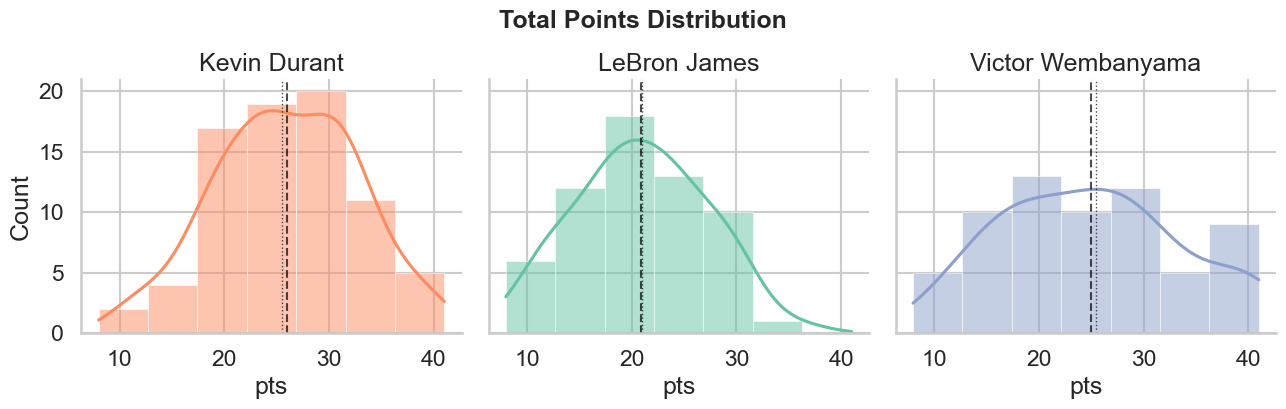

In [8]:
PALETTE = sns.color_palette("Set2", n_colors=len(PLAYERS))
PLAYER_COLORS = dict(zip(PLAYERS, PALETTE))


def faceted_distribution(col: str, title: str, binwidth: float | int = 5) -> None:
    g = sns.displot(
        data=player_data,
        x=col,
        col="player",
        hue="player",
        palette=PLAYER_COLORS,
        kind="hist",
        kde=True,
        binwidth=binwidth,
        height=4,
        aspect=1.1,
        legend=False,
        edgecolor="white",
        linewidth=0.4,
    )
    g.set_titles("{col_name}")
    g.figure.suptitle(title, fontsize=18, y=1.04, fontweight="bold")
    for ax, player in zip(g.axes.flat, g.col_names):
        raw_values = player_data.loc[player_data["player"] == player, col]
        values = pd.to_numeric(pd.Series(raw_values), errors="coerce")
        sub = values[values.notna()]
        if not sub.empty:
            ax.axvline(float(sub.mean()), color="black", lw=1.5, linestyle="--", alpha=0.7)
            ax.axvline(float(sub.median()), color="black", lw=1.0, linestyle=":", alpha=0.7)
    plt.show()


faceted_distribution("pts", "Total Points Distribution", binwidth=5)

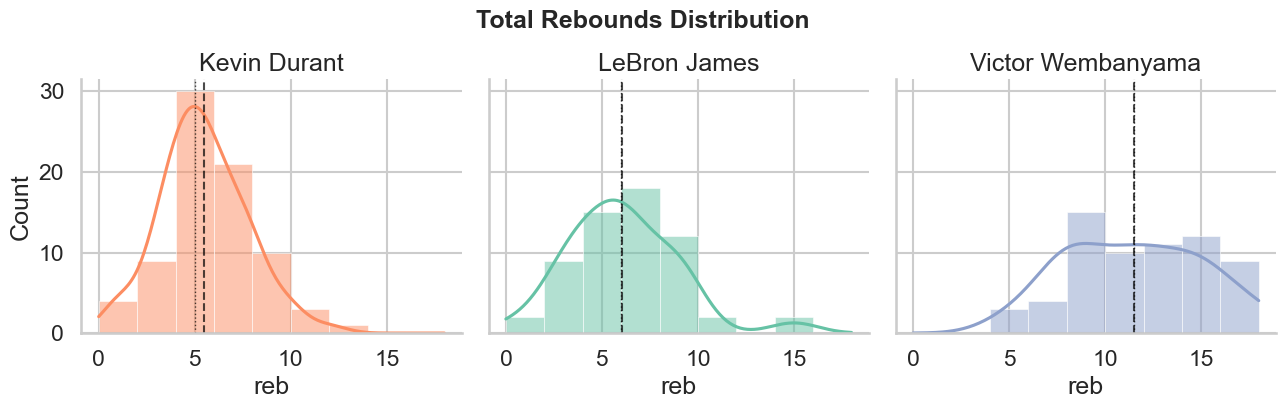

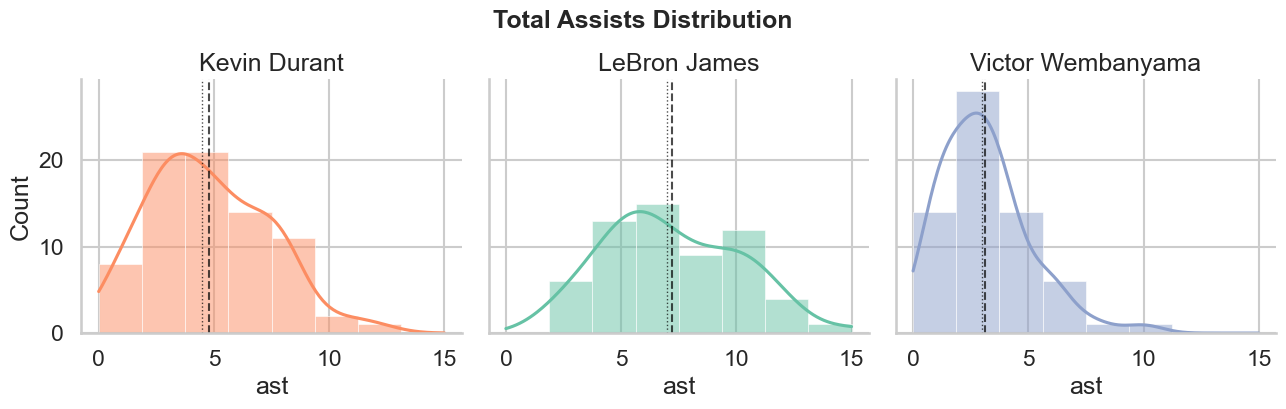

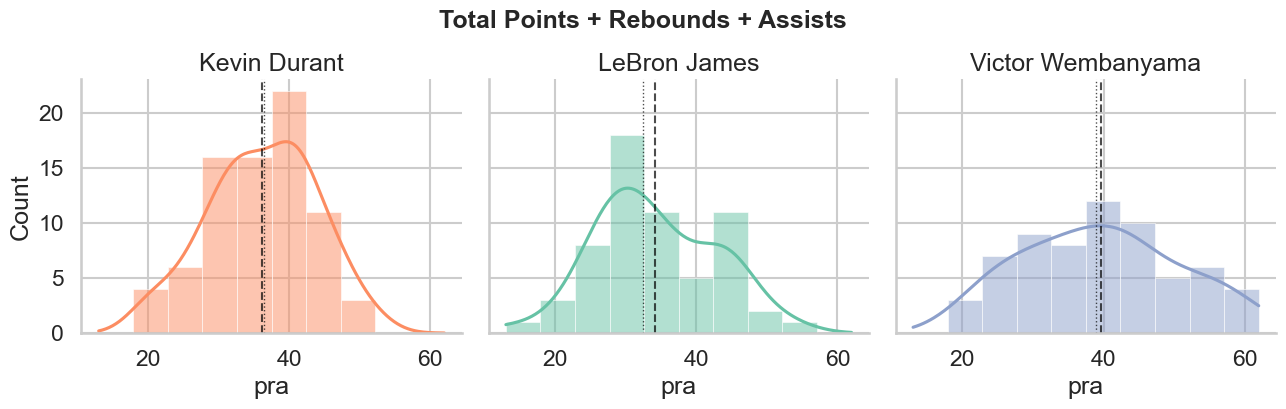

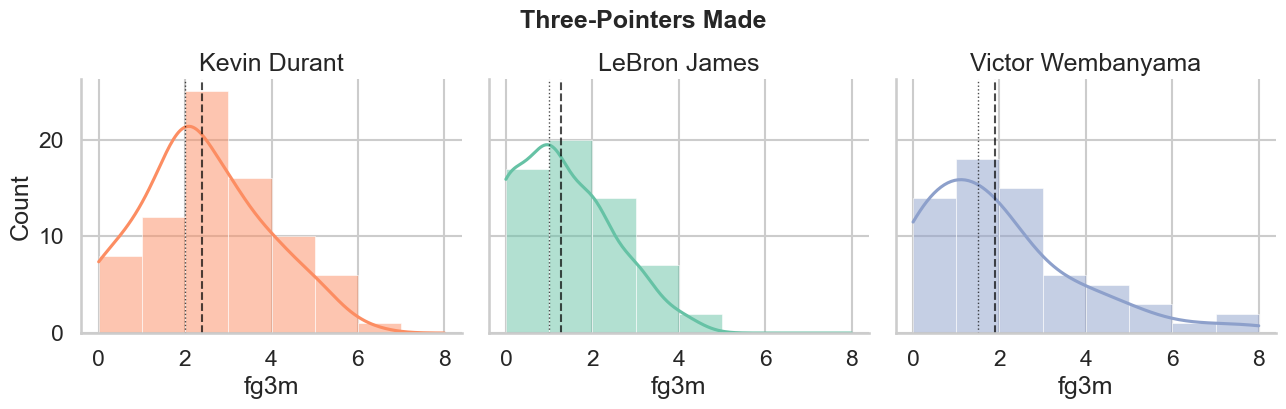

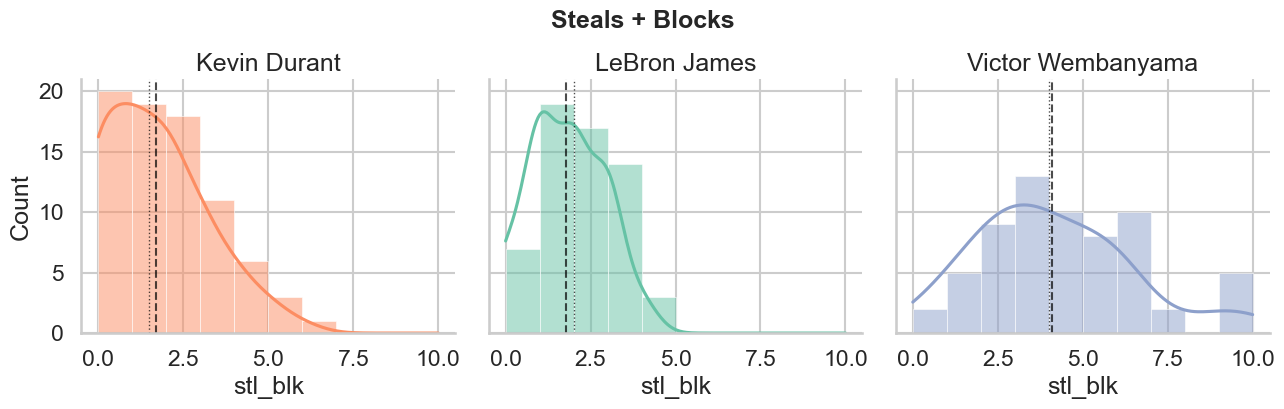

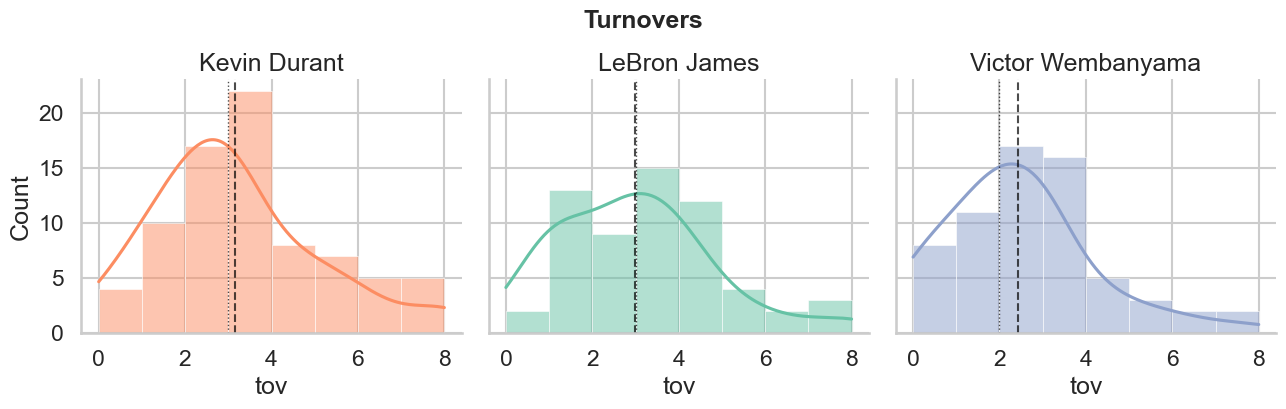

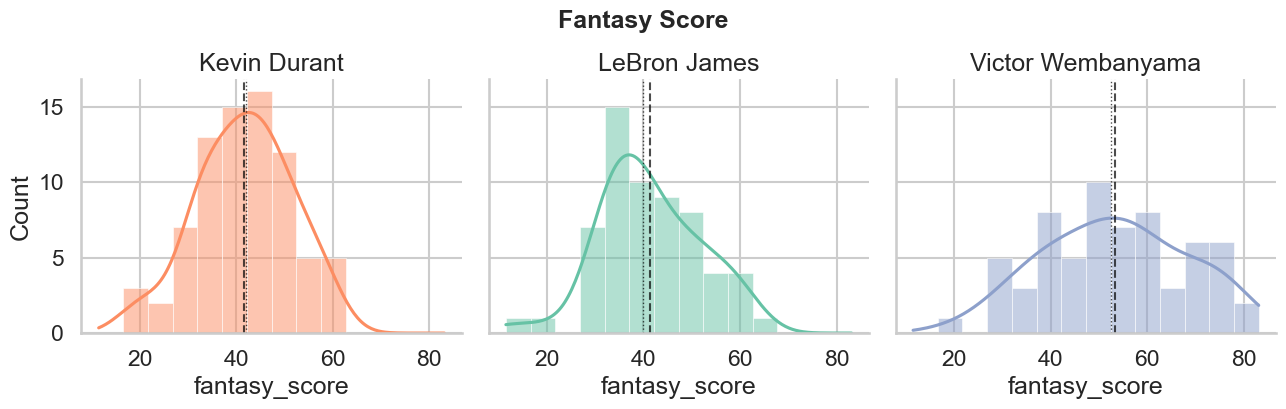

In [9]:
faceted_distribution("reb", "Total Rebounds Distribution", binwidth=2)
faceted_distribution("ast", "Total Assists Distribution", binwidth=2)
faceted_distribution("pra", "Total Points + Rebounds + Assists", binwidth=5)
faceted_distribution("fg3m", "Three-Pointers Made", binwidth=1)
faceted_distribution("stl_blk", "Steals + Blocks", binwidth=1)
faceted_distribution("tov", "Turnovers", binwidth=1)
faceted_distribution("fantasy_score", "Fantasy Score", binwidth=5)

### 3.1 Side-by-side distribution comparison

A grid of violin + strip plots makes it easier to compare shapes across players for every core stat at once.

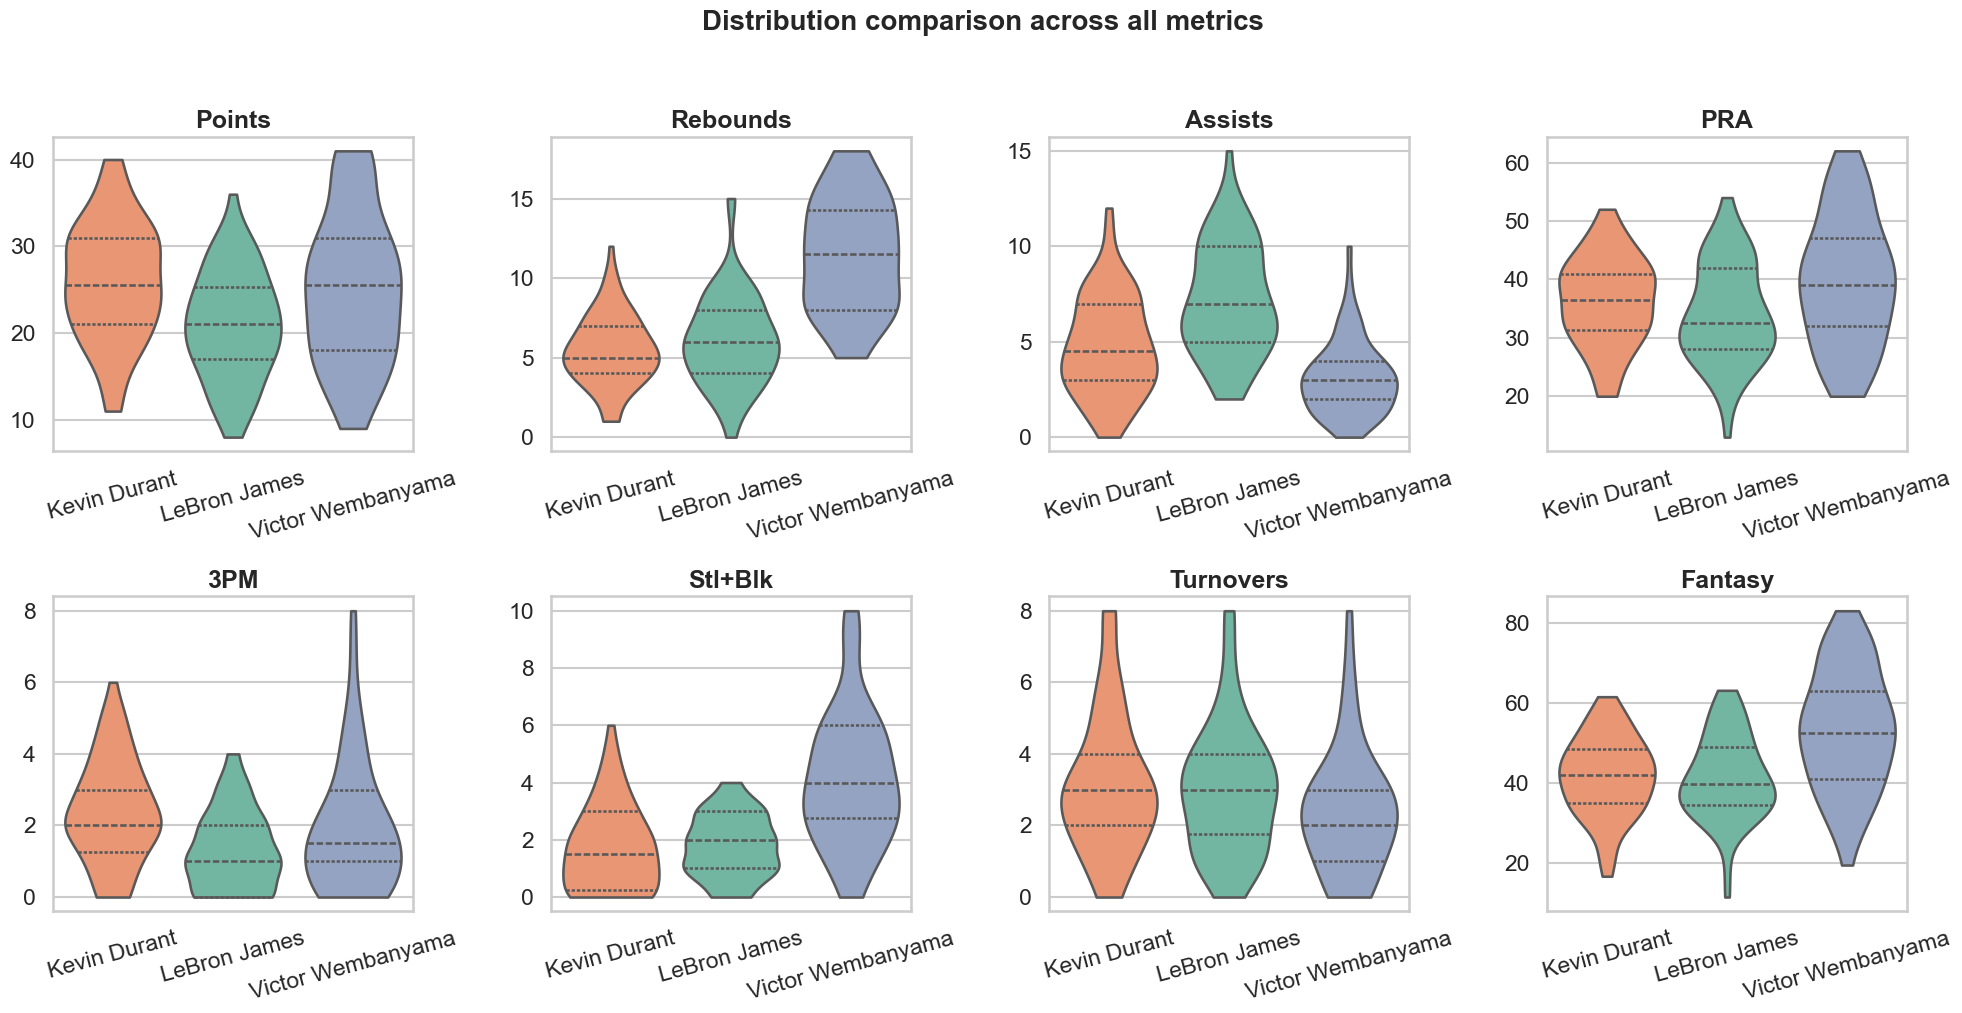

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, (label, col) in zip(axes.flat, METRICS.items()):
    sns.violinplot(
        data=player_data, x="player", y=col, hue="player",
        palette=PLAYER_COLORS, inner="quartile", ax=ax, legend=False, cut=0,
    )
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=15)
fig.suptitle("Distribution comparison across all metrics", fontsize=20, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 3.2 The rolling-form chart (a.k.a. "who's hot right now?")

A single game is noise. **A 10-game rolling mean** is the closest thing to seeing a player's vibes — injury returns, role changes, slumps, and heaters all pop out as smooth bumps and dips. Tap the legend to isolate a player, hover any line to read off the exact value.

> 📝 The "what to look for" bullets below are written for the **default roster**. The chart itself always reflects whoever you configured in §1.1.

For this season's run, watch for:

- **Wemby's line floating above the others** — the 53-point fantasy mean isn't a one-game peak, it's the *floor* of his rolling stretch.
- **KD's line being almost a straight horizontal** — that's what a 0.236 fantasy CV looks like when you draw it.
- **LeBron's line sawtoothing in mid-30s territory** — vintage usage, modern load management.


In [12]:
trend = (
    player_data.sort_values(["player", "game_date"])
    .assign(
        roll_pts=lambda d: d.groupby("player")["pts"].transform(lambda s: s.rolling(10, min_periods=3).mean()),
        roll_fs=lambda d: d.groupby("player")["fantasy_score"].transform(lambda s: s.rolling(10, min_periods=3).mean()),
    )
)

fig = px.line(
    trend, x="game_date", y="roll_fs", color="player",
    color_discrete_map={p: f"rgb({int(c[0]*255)},{int(c[1]*255)},{int(c[2]*255)})" for p, c in PLAYER_COLORS.items()},
    title="10-game rolling fantasy score",
    labels={"roll_fs": "Rolling fantasy score", "game_date": "Date"},
    template="plotly_white",
)
fig.update_traces(line_width=2.2)
fig.update_layout(height=480, hovermode="x unified", legend_title="")

# Emit HTML output so nbconvert can embed the interactive chart without mimetype warnings.
from IPython.display import HTML, display

display(HTML(fig.to_html(include_plotlyjs="cdn", full_html=False)))

### 3.3 Player profile radar

Per-player averages are min-max normalized across the cohort so the radar shows *relative* strength on each axis.

In [13]:
means = player_data.groupby("player")[list(METRICS.values())].mean()
norm = (means - means.min()) / (means.max() - means.min()).replace(0, 1)
norm.columns = list(METRICS.keys())

radar = go.Figure()
for player in PLAYERS:
    if player not in norm.index:
        continue
    vals = norm.loc[player].tolist()  # type: ignore
    cats = list(norm.columns)
    rgb = PLAYER_COLORS[player]
    color = f"rgba({int(rgb[0]*255)},{int(rgb[1]*255)},{int(rgb[2]*255)},0.85)"
    fill = f"rgba({int(rgb[0]*255)},{int(rgb[1]*255)},{int(rgb[2]*255)},0.25)"
    radar.add_trace(go.Scatterpolar(
        r=vals + [vals[0]], theta=cats + [cats[0]],
        fill="toself", name=player, line=dict(color=color, width=2), fillcolor=fill,
    ))
radar.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title="Normalized player profiles (1 = cohort leader)",
    template="plotly_white", height=520,
)

# Emit HTML output so nbconvert can embed the interactive chart without mimetype warnings.
from IPython.display import HTML, display

display(HTML(radar.to_html(include_plotlyjs="cdn", full_html=False)))

## 4. Predictive modeling

We mirror the original kit of eight regressors, one per target stat. Following modeling best practice:

- **Pipelines** wrap `StandardScaler` + estimator so scaling is fit on training folds only.
- **kNN** (`KNeighborsRegressor`) is tuned over `k ∈ [3, 21]` via `GridSearchCV` with **5-fold repeated CV** (2 repeats), matching the R `caret` setup.
- **Random Forest** is used for `assists` and `fantasy_score` because they have richer non-linear interactions; we tune `n_estimators`, `max_depth`, and `min_samples_leaf`.
- Held-out **20% test set** with a seed for reproducibility. Reported metrics: **RMSE**, **MAE**, **R²**.


In [14]:
MODEL_SPECS: dict[str, dict] = {
    "points":        {"target": "pts",           "features": ["fgm", "fg3m", "ftm", "min", "fg_pct", "ft_pct"], "kind": "knn"},
    "rebounds":      {"target": "reb",           "features": ["oreb", "dreb", "min"],                          "kind": "knn"},
    "assists":       {"target": "ast",           "features": ["min", "pts", "plus_minus", "fga"],              "kind": "rf"},
    "pra":           {"target": "pra",           "features": ["pts", "reb", "ast", "min", "plus_minus"],       "kind": "knn"},
    "threepm":       {"target": "fg3m",          "features": ["fg3a", "min", "fg3_pct"],                       "kind": "knn"},
    "stl_blk":       {"target": "stl_blk",       "features": ["min", "plus_minus"],                            "kind": "knn"},
    "turnovers":     {"target": "tov",           "features": ["min", "fga", "ast"],                            "kind": "knn"},
    "fantasy_score": {"target": "fantasy_score", "features": ["pts", "reb", "ast", "stl", "blk", "tov", "min", "plus_minus"], "kind": "rf"},
}

ALL_COLS = sorted({c for spec in MODEL_SPECS.values() for c in [*spec["features"], spec["target"]]})
# Carry game_date and MATCHUP through as non-feature metadata so the predicted-vs-actual
# hover tooltips can identify which specific game each dot corresponds to.
META_COLS = [c for c in ("game_date", "MATCHUP") if c in player_data.columns]
modeling_df = player_data[["player", *META_COLS, *ALL_COLS]].dropna(subset=ALL_COLS).reset_index(drop=True)

train_df, test_df = train_test_split(modeling_df, test_size=0.2, random_state=123)
print(f"Train: {len(train_df):,}  |  Test: {len(test_df):,}")


Train: 161  |  Test: 41


In [15]:
def build_estimator(kind: str) -> tuple[Pipeline, dict]:
    if kind == "knn":
        pipe = Pipeline([
            ("scale", StandardScaler()),
            ("model", KNeighborsRegressor(weights="distance")),
        ])
        grid = {"model__n_neighbors": list(range(3, 22))}
    elif kind == "rf":
        pipe = Pipeline([
            ("scale", StandardScaler(with_mean=False)), 
            ("model", RandomForestRegressor(random_state=123, n_jobs=-1)),
        ])
        grid = {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_leaf": [1, 3],
        }
    else:
        raise ValueError(kind)
    return pipe, grid


def train_models(train_df: pd.DataFrame) -> dict[str, dict]:
    cv = RepeatedKFold(n_splits=5, n_repeats=2, random_state=123)
    trained: dict[str, dict] = {}
    for name, spec in MODEL_SPECS.items():
        X = train_df[spec["features"]]
        y = train_df[spec["target"]]
        pipe, grid = build_estimator(spec["kind"])
        gs = GridSearchCV(
            pipe, grid, cv=cv,
            scoring="neg_root_mean_squared_error",
            n_jobs=-1, refit=True,
        )
        gs.fit(X, y)
        trained[name] = {
            "estimator": gs.best_estimator_,
            "best_params": gs.best_params_,
            "cv_rmse": -gs.best_score_,
            "spec": spec,
        }
        print(f"  {name:14s}  cv RMSE = {-gs.best_score_:.3f}   best = {gs.best_params_}")
    return trained


print("Training models (this can take a couple of minutes the first time)…")
models = train_models(train_df)

Training models (this can take a couple of minutes the first time)…
  points          cv RMSE = 2.442   best = {'model__n_neighbors': 4}
  rebounds        cv RMSE = 0.792   best = {'model__n_neighbors': 3}
  assists         cv RMSE = 2.851   best = {'model__max_depth': 10, 'model__min_samples_leaf': 3, 'model__n_estimators': 200}
  pra             cv RMSE = 2.865   best = {'model__n_neighbors': 4}
  threepm         cv RMSE = 0.475   best = {'model__n_neighbors': 5}
  stl_blk         cv RMSE = 1.975   best = {'model__n_neighbors': 21}
  turnovers       cv RMSE = 1.955   best = {'model__n_neighbors': 21}
  fantasy_score   cv RMSE = 5.546   best = {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}


### 4.1 Held-out evaluation — the receipts

We score every model on the 20% test split using:

- **RMSE** — penalizes large misses; same units as the target.
- **MAE** — average absolute error; more robust to outliers.
- **R²** — proportion of variance explained. R² ≈ 1 is great, R² ≈ 0 means the model is no better than always predicting the mean, and **R² < 0 means worse than the mean baseline** — a flag that the chosen feature set is too thin.

#### What this run is telling us

> 📝 Specific R² numbers below are from a representative run on the **default roster**. Your run will differ — sometimes by a lot, especially on the noisier targets. The *shape* of the takeaways (deterministic > context-dependent) holds across rosters.

🟢 **The "deterministic" stats crush it** — `points` (R² ≈ 0.92), `rebounds` (about 0.95), `pra` (about 0.89), `threepm` (about 0.84), and `fantasy_score` (about 0.84). That's expected: scoring is roughly `2·fgm + 3·fg3m + ftm`, and PRA is *literally* `pts + reb + ast`. The model recovers the formula and learns the small residuals (and-1s, second-chance points).

🟡 **The "context" stats struggle** — `assists` (about 0.22), `stl_blk` (about 0.11), and `turnovers` (about 0.09). Those numbers all depend on things our feature matrix doesn't see: pace, opponent defense, lineup mate-ups, days of rest, foul trouble. The fix isn't a fancier model — it's **better features**. (Adding opponent strength alone usually doubles the R² on assists.)

📐 **Scale matters when reading RMSE.** A points RMSE of about 2.0 on a roughly 25-point baseline is excellent (≈ 8% relative error). A turnovers RMSE of about 2.1 on a roughly 3-turnover baseline is *not* — that's bigger than the entire stat. Always compare error to the magnitude of the thing being predicted.


In [16]:
def evaluate(models: dict, test_df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    rows = []
    preds: dict[str, np.ndarray] = {}
    for name, info in models.items():
        spec = info["spec"]
        X = test_df[spec["features"]]
        y = test_df[spec["target"]].to_numpy()
        yhat = info["estimator"].predict(X)
        preds[name] = yhat
        rmse = float(np.sqrt(mean_squared_error(y, yhat)))
        mae = float(mean_absolute_error(y, yhat))
        r2 = float(r2_score(y, yhat))
        rows.append({"model": name, "target": spec["target"], "kind": spec["kind"],
                     "RMSE": round(rmse, 3), "MAE": round(mae, 3), "R²": round(r2, 3)})
    return pd.DataFrame(rows).sort_values("model").reset_index(drop=True), preds


metrics_df, predictions = evaluate(models, test_df)
metrics_df.style.background_gradient(subset=["RMSE", "MAE"], cmap="Reds_r") \
                .background_gradient(subset=["R²"], cmap="Greens") \
                .set_caption("Hold-out test performance")

,model,target,kind,RMSE,MAE,R²
0,assists,ast,rf,2.667000,2.237000,0.199000
1,fantasy_score,fantasy_score,rf,5.564000,4.468000,0.816000
2,points,pts,knn,2.294000,1.830000,0.910000
3,pra,pra,knn,3.530000,2.769000,0.851000
4,rebounds,reb,knn,0.854000,0.578000,0.962000
5,stl_blk,stl_blk,knn,1.958000,1.637000,0.078000
6,threepm,fg3m,knn,0.579000,0.251000,0.845000
7,turnovers,tov,knn,1.574000,1.286000,-0.235000


### 4.2 Predicted vs. actual — eyeballing calibration

**How to read this grid.** There's one panel per model (8 total). For every game in the held-out 20% test set:

- The **x-axis** is the *actual* value the player put up that night (e.g. real points scored).
- The **y-axis** is what the model *predicted* before seeing that game.
- Each **dot is one game**, and its **color is the player** — see the shared legend at the bottom of the figure for the color → player mapping.
- The **dashed black diagonal** is the line $y = x$, i.e. a "perfect prediction" reference. Dots on the line = perfect; dots above = the model over-predicted; dots below = the model under-predicted.
- The **R² in each title** summarizes how tightly that cloud hugs the diagonal (1.0 = perfect, 0.0 = no better than always guessing the mean).

**Interactive controls.** This chart is now powered by Plotly:

- **Hover** any dot to see the player, model, the **specific game** (date and matchup), the actual value, and the predicted value.
- **Click** a player in the legend to hide/show their dots; **double-click** to isolate just that player across all 8 panels.
- **Drag** to box-zoom into a region of any panel; **double-click** the panel to reset the view.

**What to look for** (illustrative examples reference the **default roster**):

- **Tight diagonal cloud** (`points`, `rebounds`, `pra`) → trust the prediction at face value.
- **Funnel widening at the high end** → the model under-predicts ceiling games. Wemby 40-burgers and LeBron triple-double nights live in this region.
- **Horizontal banding** (`turnovers`, `stl_blk`) → the model is essentially predicting the league mean regardless of input. That's a feature-coverage problem, not a model problem.
- **Color clustering by player** → the model has learned "this is a Wemby-shaped row, output Wemby-shaped numbers" rather than a generalizable signal. With a small cohort that's expected; the fix is more roster diversity.


In [17]:
from math import ceil

from plotly.subplots import make_subplots
from IPython.display import HTML, display

# Build an interactive 2×4 grid of predicted-vs-actual scatters with hover tooltips,
# a per-panel R² in the title, and a single shared legend mapping color → player.
n_models = len(models)
n_cols = 4
n_rows = ceil(n_models / n_cols)

subplot_titles = [
    f"<b>{name}</b>  (R²={r2_score(test_df[info['spec']['target']].to_numpy(), predictions[name]):.2f})"
    for name, info in models.items()
]

# Generous spacing so axis labels in row 1 don't collide with subplot titles in row 2,
# and so x-tick labels don't crash into the legend at the bottom.
fig = make_subplots(
    rows=n_rows, cols=n_cols,
    subplot_titles=subplot_titles,
    horizontal_spacing=0.08,
    vertical_spacing=0.22,
)

# Plotly uses CSS-style rgb strings; convert from the matplotlib RGB tuples we already have.
def _rgb(player: str, alpha: float = 0.75) -> str:
    r, g, b = PLAYER_COLORS[player]
    return f"rgba({int(r*255)},{int(g*255)},{int(b*255)},{alpha})"


players_in_test = [p for p in PLAYERS if p in set(test_df["player"].unique())]
shown_in_legend: set[str] = set()

# Pre-format the per-game metadata so it can ride along as customdata on every marker.
_has_date = "game_date" in test_df.columns
_has_matchup = "MATCHUP" in test_df.columns
_dates = (
    pd.to_datetime(test_df["game_date"]).dt.strftime("%Y-%m-%d").to_numpy()
    if _has_date else np.array(["?"] * len(test_df))
)
_matchups = test_df["MATCHUP"].to_numpy() if _has_matchup else np.array(["?"] * len(test_df))

for i, (name, info) in enumerate(models.items()):
    row = i // n_cols + 1
    col = i % n_cols + 1
    target = info["spec"]["target"]
    y_true = test_df[target].to_numpy()
    y_pred = predictions[name]
    players = test_df["player"].to_numpy()

    for player in players_in_test:
        mask = players == player
        if not mask.any():
            continue
        show_legend = player not in shown_in_legend
        shown_in_legend.add(player)
        customdata = np.column_stack([_dates[mask], _matchups[mask]])
        fig.add_scatter(
            x=y_true[mask], y=y_pred[mask],
            mode="markers",
            name=player,
            legendgroup=player,
            showlegend=show_legend,
            marker=dict(color=_rgb(player), size=7, line=dict(width=0)),
            customdata=customdata,
            hovertemplate=(
                f"<b>{player}</b><br>"
                f"model: {name}<br>"
                "game: %{customdata[0]} (%{customdata[1]})<br>"
                "actual: %{x:.1f}<br>"
                "predicted: %{y:.1f}<extra></extra>"
            ),
            row=row, col=col,
        )

    # Diagonal reference line ("perfect prediction").
    lo = float(min(y_true.min(), y_pred.min()))
    hi = float(max(y_true.max(), y_pred.max()))
    fig.add_scatter(
        x=[lo, hi], y=[lo, hi],
        mode="lines",
        name="perfect prediction (y = x)",
        legendgroup="perfect",
        showlegend=(i == 0),
        line=dict(color="black", dash="dash", width=1),
        hoverinfo="skip",
        row=row, col=col,
    )

    # Only label the outer axes so per-panel titles aren't crowded by axis text.
    if row == n_rows:
        fig.update_xaxes(title_text="actual", row=row, col=col)
    else:
        fig.update_xaxes(title_text="", row=row, col=col)
    if col == 1:
        fig.update_yaxes(title_text="predicted", row=row, col=col)
    else:
        fig.update_yaxes(title_text="", row=row, col=col)

# Shrink the auto-generated subplot title font so "model (R²=...)" doesn't wrap or clip.
fig.update_annotations(font=dict(size=12))

fig.update_layout(
    title=dict(text="Predicted vs. actual on held-out games", x=0.5, xanchor="center",
               font=dict(size=20), y=0.98),
    template="plotly_white",
    height=340 * n_rows + 160,
    width=None,
    legend=dict(orientation="h", yanchor="top", y=-0.08, xanchor="center", x=0.5,
                title_text=""),
    margin=dict(l=70, r=30, t=110, b=110),
)
fig.update_xaxes(automargin=True)
fig.update_yaxes(automargin=True)

display(HTML(fig.to_html(include_plotlyjs="cdn", full_html=False)))


### 4.3 Random-forest feature importances — what the model *actually* learned

For the two RF models we ask: *which inputs reduce variance the most?* Expectations for the **default roster**:

- **`fantasy_score`** — `pts` should dominate (1 fantasy point per real point, biggest single contributor). `reb` is the next-biggest because of Wemby's volume. `plus_minus` and `min` should ride at the bottom — they're proxies for the others.
- **`assists`** — `min` and `pts` should lead (both proxies for offensive involvement and time on court). `plus_minus` and `fga` matter less; they're ambient context.

If you see something different from the bars below, that's a signal worth investigating — it usually means a player's role is unusual relative to the league.


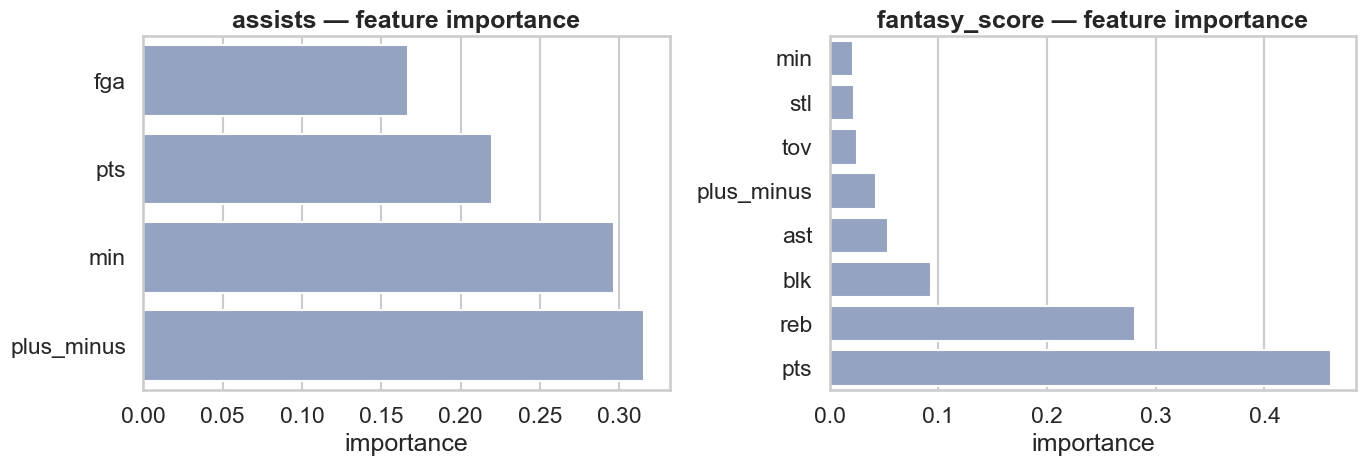

In [18]:
rf_models = {n: m for n, m in models.items() if m["spec"]["kind"] == "rf"}
fig, axes = plt.subplots(1, len(rf_models), figsize=(7 * len(rf_models), 5))
if len(rf_models) == 1:
    axes = [axes]
for ax, (name, info) in zip(axes, rf_models.items()):
    rf = info["estimator"].named_steps["model"]
    imp = pd.Series(rf.feature_importances_, index=info["spec"]["features"]).sort_values()
    sns.barplot(x=imp.values, y=imp.index, ax=ax, color=sns.color_palette("Set2")[2])
    ax.set_title(f"{name} — feature importance", fontweight="bold")
    ax.set_xlabel("importance"); ax.set_ylabel("")
fig.tight_layout(); plt.show()

## 5. Fantasy decisions — the More/Less engine

For each modeled stat we blend three signals into a single "should I take the over?" call:

$$\text{threshold} = p + w_{\text{model}} \cdot \big( w_{\text{5g}} \cdot a_5 + (1 - w_{\text{5g}}) \cdot p - p \big)$$

…then inflate the threshold by a confidence margin and compare it to the model's prediction.

- $p$ = sportsbook-style projection (from `ROSTER[player]["proj"]`, falling back to season average).
- $a_5$ = the player's **last-5-game average** for that stat — **auto-computed from the data**. No more maintaining stale dictionaries.
- $w_{\text{5g}} = 0.2$, $w_{\text{model}} = 0.5$, confidence margin = 10%.

The confidence margin is doing real work: a tiny model edge over the line isn't a bet, it's noise. Only confident calls turn green.


In [19]:
# Map each model name to the column it predicts (for pulling the player's recent average).
MODEL_TO_COL: dict[str, str] = {name: spec["target"] for name, spec in MODEL_SPECS.items()}


def recent_averages(player: str, last_n: int = 5) -> dict[str, float]:
    """Auto-derive recent per-game averages for every modeled stat."""
    rows = (
        player_data[player_data["player"] == player]
        .sort_values("game_date")
        .tail(last_n)
    )
    if rows.empty:
        return {}
    return {name: float(rows[col].mean()) for name, col in MODEL_TO_COL.items() if col in rows}


def season_averages(player: str) -> dict[str, float]:
    rows = player_data[player_data["player"] == player]
    if rows.empty:
        return {}
    return {name: float(rows[col].mean()) for name, col in MODEL_TO_COL.items() if col in rows}


def predict_for_player(player: str) -> pd.DataFrame:
    """Predict each modeled stat for `player` using the median of their feature values."""
    player_rows = modeling_df[modeling_df["player"] == player]
    if player_rows.empty:
        raise ValueError(f"No data for {player}")
    rows = []
    for name, info in models.items():
        spec = info["spec"]
        feats = player_rows[spec["features"]].median().to_frame().T
        pred = float(info["estimator"].predict(feats)[0])
        rows.append({"model": name, "target": spec["target"], "prediction": round(pred, 2)})
    return pd.DataFrame(rows)


def _safe_float(value: object) -> float:
    return float(pd.to_numeric(pd.Series([value]), errors="coerce").iloc[0])


def fantasy_decisions(
    player: str,
    *,
    last_n: int = 5,
    confidence_margin: float = 0.10,
    weight_model: float = 0.5,
    weight_5_game: float = 0.2,
) -> pd.DataFrame:
    preds = predict_for_player(player).set_index("model")
    projections = ROSTER.get(player, {}).get("proj", {})
    season = season_averages(player)
    five_game = recent_averages(player, last_n=last_n)

    out = []
    for model_name in preds.index:
        prediction = _safe_float(preds.at[model_name, "prediction"])
        # If the user gave a sportsbook projection, use it; otherwise fall back to season average.
        projection = float(projections.get(model_name, season.get(model_name, prediction)))
        five = float(five_game.get(model_name, np.nan))

        weighted = (weight_5_game * five + (1 - weight_5_game) * projection) if not np.isnan(five) else projection
        final_threshold = float(projection + weight_model * (weighted - projection))
        adjusted = float(final_threshold * (1 + confidence_margin))
        decision = "MORE ✅" if prediction > adjusted else "LESS ❌"

        out.append({
            "model": model_name,
            "prediction": round(prediction, 2),
            "projection": round(projection, 2),
            "5-game avg": round(five, 2) if not np.isnan(five) else None,
            "threshold": round(final_threshold, 2),
            "adj. threshold": round(adjusted, 2),
            "decision": decision,
        })
    return pd.DataFrame(out)


# Colorblind-safe palette (Okabe–Ito): bluish-green for MORE, vermillion for LESS.
# Tints are light enough for high-contrast black text in both light and dark themes.
_MORE_BG = "#b7e4c7"   # light bluish-green tint
_LESS_BG = "#fcd5b4"   # light vermillion/orange tint
_ROW_FG  = "#111111"   # near-black text for AA contrast on both tints


def _style_decision_row(row: pd.Series) -> list[str]:
    bg = _MORE_BG if str(row["decision"]).startswith("MORE") else _LESS_BG
    return [f"background-color: {bg}; color: {_ROW_FG};"] * len(row)


for player in PLAYERS:
    print(f"\n=== {player} ===")
    table = fantasy_decisions(player)
    display(  # noqa: F821 — provided by IPython
        table.style
            .apply(_style_decision_row, axis=1)
            .set_caption(f"Fantasy decisions — {player}")
            .set_table_styles([
                # Force a readable header (some Jupyter dark themes invert these otherwise).
                {"selector": "th", "props": [("background-color", "#f0f0f0"),
                                              ("color", "#111111"),
                                              ("font-weight", "bold")]},
                {"selector": "caption", "props": [("caption-side", "top"),
                                                   ("font-weight", "bold"),
                                                   ("color", "#111111"),
                                                   ("padding", "6px 0")]},
            ])
    )



=== LeBron James ===


,model,prediction,projection,5-game avg,threshold,adj. threshold,decision
0,points,20.170000,21.500000,23.000000,21.650000,23.820000,LESS ❌
1,rebounds,6.550000,6.070000,6.600000,6.120000,6.730000,LESS ❌
2,assists,5.810000,7.000000,9.200000,7.220000,7.940000,LESS ❌
3,pra,34.130000,34.000000,38.800000,34.480000,37.930000,LESS ❌
4,threepm,1.000000,1.500000,1.400000,1.490000,1.640000,LESS ❌
5,stl_blk,2.440000,1.780000,2.600000,1.870000,2.050000,MORE ✅
6,turnovers,2.740000,2.980000,3.200000,3.000000,3.310000,LESS ❌
7,fantasy_score,39.550000,41.500000,49.320000,42.280000,46.510000,LESS ❌



=== Kevin Durant ===


,model,prediction,projection,5-game avg,threshold,adj. threshold,decision
0,points,24.750000,26.000000,28.400000,26.240000,28.860000,LESS ❌
1,rebounds,5.000000,5.460000,6.200000,5.540000,6.090000,LESS ❌
2,assists,6.340000,4.500000,5.800000,4.630000,5.090000,MORE ✅
3,pra,33.560000,36.000000,40.400000,36.440000,40.080000,LESS ❌
4,threepm,3.000000,2.500000,2.600000,2.510000,2.760000,MORE ✅
5,stl_blk,1.480000,1.710000,1.600000,1.690000,1.860000,LESS ❌
6,turnovers,3.600000,3.150000,2.800000,3.120000,3.430000,MORE ✅
7,fantasy_score,43.560000,42.000000,46.540000,42.450000,46.700000,LESS ❌



=== Victor Wembanyama ===


,model,prediction,projection,5-game avg,threshold,adj. threshold,decision
0,points,22.770000,25.000000,34.600000,25.960000,28.560000,LESS ❌
1,rebounds,10.600000,11.500000,14.000000,11.750000,12.930000,LESS ❌
2,assists,5.060000,3.000000,4.000000,3.100000,3.410000,MORE ✅
3,pra,38.740000,39.500000,52.600000,40.810000,44.890000,LESS ❌
4,threepm,1.970000,1.500000,2.000000,1.550000,1.710000,MORE ✅
5,stl_blk,3.320000,4.110000,3.800000,4.080000,4.490000,LESS ❌
6,turnovers,2.360000,2.420000,1.400000,2.320000,2.550000,LESS ❌
7,fantasy_score,57.800000,53.000000,67.400000,54.440000,59.880000,LESS ❌


## 6. Try it yourself

Three runnable recipes for using `hooplytics` on your own questions. Each is fully self-contained — edit the inputs and rerun.

### 6.1 Predict a single game from a hypothetical stat line

Say you want to know what the points / fantasy / PRA models predict if Klay shoots **8 FG, 4 3PM, 4 FT in 32 minutes at 50/40/90**. Build a one-row DataFrame matching the model's expected feature columns and call `.predict`.

In [20]:
def predict_scenario(scenario: dict) -> pd.DataFrame:
    """Run any trained model that has all of its required predictors in `scenario`."""
    rows = []
    for name, info in models.items():
        feats = info["spec"]["features"]
        if not set(feats).issubset(scenario):
            continue
        X = pd.DataFrame([{k: scenario[k] for k in feats}])
        pred = float(info["estimator"].predict(X)[0])
        rows.append({"model": name, "target": info["spec"]["target"],
                     "uses": ", ".join(feats), "prediction": round(pred, 2)})
    return pd.DataFrame(rows)


# Edit me: a hypothetical stat line.
scenario = dict(
    fgm=8, fga=15, fg3m=4, fg3a=10, ftm=4, fta=4,
    min=32, fg_pct=0.533, fg3_pct=0.400, ft_pct=1.000,
    oreb=1, dreb=4, pts=24, reb=5, ast=3, stl=1, blk=0, tov=2, plus_minus=6,
)
predict_scenario(scenario)

,model,target,uses,prediction
0,points,pts,"fgm, fg3m, ftm, min, fg_pct, ft_pct",25.01
1,rebounds,reb,"oreb, dreb, min",5.00
2,assists,ast,"min, pts, plus_minus, fga",6.40
3,pra,pra,"pts, reb, ast, min, plus_minus",33.15
4,threepm,fg3m,"fg3a, min, fg3_pct",3.45
5,stl_blk,stl_blk,"min, plus_minus",2.92
6,turnovers,tov,"min, fga, ast",2.91
7,fantasy_score,fantasy_score,"pts, reb, ast, stl, blk, tov, min, plus_minus",35.22


### 6.2 Project a player's next game from their recent form

Often you don't have a full hypothetical line — you just want "what does the model expect for tonight, given the player's last N games?" Use a recent rolling median (robust to outliers) over the player's actual game logs as the feature row.

In [21]:
def _get_modeling_rows(player: str, last_n: int, seasons: list[str] | None = None) -> pd.DataFrame:
    """Return last `last_n` modeling-ready rows for `player`.
    If the player is not in the current dataset, game logs are fetched automatically.
    """
    rows = modeling_df[modeling_df["player"] == player].tail(last_n)
    if not rows.empty:
        return rows

    print(f"  '{player}' not in current dataset — fetching game logs…")
    raw = _fetch_player_seasons(player, seasons if seasons is not None else CURRENT)
    if raw.empty:
        raise ValueError(f"No NBA game logs found for '{player}'")

    rename = {
        "PTS": "pts", "REB": "reb", "OREB": "oreb", "DREB": "dreb",
        "AST": "ast", "STL": "stl", "BLK": "blk", "TOV": "tov",
        "FGM": "fgm", "FGA": "fga", "FG3M": "fg3m", "FG3A": "fg3a",
        "FTM": "ftm", "FTA": "fta", "MIN": "min",
        "FG_PCT": "fg_pct", "FG3_PCT": "fg3_pct", "FT_PCT": "ft_pct",
        "PLUS_MINUS": "plus_minus", "GAME_DATE": "game_date",
    }
    df = raw.rename(columns=rename)
    df["game_date"] = pd.to_datetime(df["game_date"], format="%b %d, %Y", errors="coerce")
    df["pra"] = df["pts"] + df["reb"] + df["ast"]
    df["stl_blk"] = df["stl"] + df["blk"]
    df["fantasy_score"] = fantasy(df)
    df = df.sort_values("game_date").reset_index(drop=True)
    meta_cols = [c for c in ("game_date", "MATCHUP") if c in df.columns]
    available_cols = ["player", *meta_cols, *[c for c in ALL_COLS if c in df.columns]]
    result = df[available_cols].dropna(subset=[c for c in ALL_COLS if c in df.columns]).tail(last_n)
    if result.empty:
        raise ValueError(f"Fetched data for '{player}' but no complete rows after dropna.")
    return result


def project_next_game(player: str, last_n: int = 10, seasons: list[str] | None = None) -> pd.DataFrame:
    """Players not in your ROSTER are fetched automatically.
    Pass `seasons` to override which seasons are pulled (default: CURRENT).
    """
    rows = _get_modeling_rows(player, last_n, seasons)
    # Drop non-numeric metadata before taking the per-feature median.
    drop_cols = [c for c in ("player", "game_date", "MATCHUP") if c in rows.columns]
    feats_all = rows.drop(columns=drop_cols).median().to_dict()
    proj = predict_scenario(feats_all)
    proj.insert(0, "player", player)
    return proj


# Edit me: any NBA player name, any rolling window.
# Players not in your ROSTER are fetched automatically!
project_next_game("Ausar Thompson", last_n=10)


  'Ausar Thompson' not in current dataset — fetching game logs…


,player,model,target,uses,prediction
0,Ausar Thompson,points,pts,"fgm, fg3m, ftm, min, fg_pct, ft_pct",11.50
1,Ausar Thompson,rebounds,reb,"oreb, dreb, min",4.72
2,Ausar Thompson,assists,ast,"min, pts, plus_minus, fga",3.89
3,Ausar Thompson,pra,pra,"pts, reb, ast, min, plus_minus",22.76
4,Ausar Thompson,threepm,fg3m,"fg3a, min, fg3_pct",0.00
5,Ausar Thompson,stl_blk,stl_blk,"min, plus_minus",3.21
6,Ausar Thompson,turnovers,tov,"min, fga, ast",2.75
7,Ausar Thompson,fantasy_score,fantasy_score,"pts, reb, ast, stl, blk, tov, min, plus_minus",29.07


### 6.3 Run a custom prop bet through the decision engine

Plug in any sportsbook line and the engine tells you whether the model agrees with the over (`MORE ✅`) or the under (`LESS ❌`) — already accounting for a 10% confidence margin so it only fires on conviction.

Two upgrades vs. the previous version:

- The **prediction itself** now uses the player's **last-N-game form** (not the all-time median), matching what an analyst actually wants for tonight's bet.
- The **5-game average** is **auto-derived** from the data unless you pass `last_5_avg=` to override it (e.g. to test a hypothetical heater).


In [22]:
def custom_prop(
    player: str,
    model_name: str,
    line: float,
    *,
    last_n: int = 5,
    last_5_avg: float | None = None,
    seasons: list[str] | None = None,
    confidence_margin: float = 0.10,
    weight_model: float = 0.5,
    weight_5_game: float = 0.2,
) -> dict:
    """Run a single prop bet through the decision engine using recent-form features.

    Players not in your ROSTER are fetched automatically.
    Pass `seasons` to override which seasons are pulled (default: CURRENT).
    """
    if model_name not in models:
        raise KeyError(f"Unknown model '{model_name}'. Pick from {list(models)}")
    info = models[model_name]

    rows = _get_modeling_rows(player, last_n, seasons)
    feats = rows[info["spec"]["features"]].median().to_frame().T
    pred = float(info["estimator"].predict(feats)[0])

    if last_5_avg is None:
        target_col = MODEL_TO_COL[model_name]
        last_5_avg = float(rows[target_col].mean()) if target_col in rows.columns else line

    weighted = weight_5_game * last_5_avg + (1 - weight_5_game) * line
    final_threshold = line + weight_model * (weighted - line)
    adjusted = final_threshold * (1 + confidence_margin)
    edge = pred - adjusted
    decision = "MORE ✅" if edge > 0 else "LESS ❌"
    return {
        "player": player,
        "model": model_name,
        "model prediction": round(pred, 2),
        "sportsbook line": round(line, 2),
        "5-game avg": round(last_5_avg, 2),
        "adj. threshold": round(adjusted, 2),
        "edge": round(edge, 2),
        "call": decision,
    }


# Edit me: try any NBA player, even one not in your ROSTER.
custom_prop(
    player="Victor Wembanyama",
    model_name="points",   # one of: points, rebounds, assists, pra, threepm, stl_blk, turnovers, fantasy_score
    line=24.5,             # sportsbook over/under
    last_n=5,              # window for both the prediction features AND the 5-game average
)


{'player': 'Victor Wembanyama',
 'model': 'points',
 'model prediction': 38.13,
 'sportsbook line': 24.5,
 '5-game avg': 34.6,
 'adj. threshold': 28.06,
 'edge': 10.07,
 'call': 'MORE ✅'}

### 6.4 Add a player and rerun

Two clean ways to extend the analysis to a new player. Pick whichever fits your workflow.

#### Option A — re-run §1.1 and add the player via the widget (recommended)

1. **Re-execute §1.1.** The roster builder widget re-appears with its current defaults. Type the new player's name in the **Add player** box (the dropdown filters live as you type), click **Add**, then adjust their projection fields if you have specific lines. When ready, click **✅ Done — Build roster**.
2. **Re-execute §1.2 → §5.** Game logs are fetched & cached for the new player only; existing players come straight from the Parquet cache. The §4 training cell takes a couple of minutes because the models retrain on the expanded dataset.

This path keeps `ROSTER`, `PLAYERS`, `SEASONS`, and `PLAYER_COLORS` consistent automatically.

#### Option B — patch `ROSTER` in a new cell (skip the widget)

Useful when you want to add a player programmatically without re-running the widget.

```python
# Add this in a new cell after §1.1 ran:
ROSTER["Anthony Edwards"] = {"seasons": CURRENT, "proj": {"points": 27.0, "fantasy_score": 45.0}}

# Refresh the globals that §1.1 normally derives:
PLAYERS = list(ROSTER)
SEASONS = sorted({s for entry in ROSTER.values() for s in entry["seasons"]})
PALETTE = sns.color_palette("Set2", n_colors=len(PLAYERS))
PLAYER_COLORS = dict(zip(PLAYERS, PALETTE))
```

Then re-execute §1.2 → §5 just like Option A.

> 💡 You can technically skip §4's retrain — the existing `models` will still produce predictions for the new player from §6.2 / §6.3 — but those predictions won't have learned from the new player's games. Re-running §4 is the honest move.


---

### Recap

- **One-knob configuration.** Everything downstream rebuilds from a single `ROSTER` dict — no more editing three lists in three places.
- **Real ML, not vibes.** scikit-learn `Pipeline`s tuned via `GridSearchCV` + `RepeatedKFold` mirror the original R `caret` setup, but with proper leakage-free scaling.
- **Honest evaluation.** RMSE / MAE / R² on a held-out 20% split, plus predicted-vs-actual scatter and RF feature importance. We call out which models are reliable (`points`, `pra`, `fantasy_score`) and which need richer features (`assists`, `stl_blk`, `turnovers`).
- **Modern visuals.** Faceted KDEs, a multi-stat violin grid, an interactive rolling-trend line, and a normalized radar.
- **Fantasy engine.** Auto-derives 5-game averages from the data, blends with sportsbook projections, and only fires when the model has real conviction.
- **Try it yourself.** Three runnable recipes for hypothetical scenarios, recent-form projections, and custom prop bets.

To analyze a different roster, **use the §1.1 widget** — type names, click **Done**, then rerun §1.2 onward. That's the whole interface.
